## Welcome to my Assignment 2 - Bui Viet Toan Hoang - 60858397


## Objectives of this assignment

In this assignment, you will work on the Quora Question Pairs (QQP) datset detailed below. The first two tasks will help you get familiar with the data, and the remaining requires you to implement deep neural networks.


**About the Quora Question Pairs (QQP) Dataset**

Description: A large dataset of 400k+ question pairs from Quora, labeled whether they are duplicates (semantically the same) or not. It features informal, noisy text with class imbalance, hard positives (low lexical overlap) and hard negatives (high overlap, different meaning). QQP is practically relevant for deduplicating FAQs, search, and support systems. Working on QQP builds transferable skills, such as text preprocessing, model comparison, threshold tuning, error analysis, and deployment-minded reasoning about real applications.

**Get familiar with the dataset**

I am installing all the dependencies, libraries, packages for the whole assignment 2 in this code cell, so that we can run once and no need to run and import the libraries task by task.

In [3]:
# Packages used in this notebook, with versions installed in the comp6420-a2 venv (I am doing my assignmenr in my VScode, so 
# I created a .venv and installed the packages there, and I am using that venv in my Jupyter notebook to run the code):
# datasets==4.8.5
# numpy==2.4.4
# nltk==3.9.4
# scikit-learn==1.8.0
# torch==2.11.0+cu128
# transformers==5.7.0
# accelerate==1.13.0
# evaluate==0.4.6
# pandas==3.0.2
# matplotlib==3.10.9
# seaborn==0.13.2
# ipython==9.13.0

import sys
import platform
import subprocess
from datasets import load_dataset
import numpy as np
import pandas as pd
import nltk
from collections import Counter
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer
from nltk.util import bigrams
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import evaluate
import accelerate
from IPython.display import display

# I am downloading the NLTK resources required for Tasks 1 and 2.
for package in ["punkt", "punkt_tab", "averaged_perceptron_tagger_eng", "universal_tagset"]:
    nltk.download(package, quiet=True)


This is AI-generated code from Claude, I asked Claude to help me make the code cell for checking my whole system, my local GPUs, everything; cause I am running my project on my local machine (on VSCode). This is just for checking purposes and nothing relating to the assignment specification, so I did not make any changes to this code cell below.

Here is the prompt I used: "Please help me generate a standalone Python script that uses `sys`, `platform`, `subprocess`, and `torch` to print detailed Python, system, CUDA, cuDNN, GPU, PyTorch, memory, and `nvidia-smi` diagnostic information with clean formatting and graceful error handling.
"



In [4]:
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

print("\nProcessor:")
print(platform.processor())

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

print("\nPyTorch CUDA version:")
print(torch.version.cuda)

print("\ncuDNN version:")
print(torch.backends.cudnn.version())

print("\nGPU device count:")
print(torch.cuda.device_count())

if torch.cuda.is_available():
    device_id = 0
    print("\nGPU name:")
    print(torch.cuda.get_device_name(device_id))

    print("\nGPU properties:")
    props = torch.cuda.get_device_properties(device_id)
    print("Name:", props.name)
    print("Total memory (GB):", round(props.total_memory / 1024**3, 2))
    print("Compute capability:", f"{props.major}.{props.minor}")

    print("\nCurrent CUDA device:")
    print(torch.cuda.current_device())

    print("\nAllocated memory (GB):")
    print(round(torch.cuda.memory_allocated(device_id) / 1024**3, 4))

    print("\nReserved memory (GB):")
    print(round(torch.cuda.memory_reserved(device_id) / 1024**3, 4))
else:
    print("\nNo CUDA GPU detected by PyTorch.")

print("\nnvidia-smi:")
try:
    result = subprocess.run(
        ["nvidia-smi"],
        capture_output=True,
        text=True,
        check=True
    )
    print(result.stdout)
except Exception as e:
    print("Could not run nvidia-smi:", e)


Python executable:
c:\Users\tonyh_yxuq8za\Desktop\comp6420-nlp-a2\.venv\Scripts\python.exe

Python version:
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

Platform:
Windows-10-10.0.26200-SP0

Processor:
Intel64 Family 6 Model 151 Stepping 2, GenuineIntel

PyTorch version:
2.11.0+cu128

CUDA available:
True

PyTorch CUDA version:
12.8

cuDNN version:
91900

GPU device count:
1

GPU name:
NVIDIA GeForce RTX 4070 SUPER

GPU properties:
Name: NVIDIA GeForce RTX 4070 SUPER
Total memory (GB): 11.99
Compute capability: 8.9

Current CUDA device:
0

Allocated memory (GB):
0.0

Reserved memory (GB):
0.0

nvidia-smi:
Thu May 21 16:32:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model |

This code cell is used to load the QQP dataset from GLUE benchmark through HF platform. This is the default code cell from Assignment 2 notebook so I keep using it.

My explanation: 

This cell loads the QQP dataset and separates it into training and validation splits. The validation split is used as the test set for this assignment. It then extracts both question columns and the labels, so they can be used later for preprocessing, analysis, and model evaluation.

In [5]:
# 1) Load QQP
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"]
eval_ds  = ds["validation"]

q1_tr = list(train_ds["question1"])
q2_tr = list(train_ds["question2"])
y_tr  = np.array(train_ds["label"])

q1_te = list(eval_ds["question1"])
q2_te = list(eval_ds["question2"])
y_te  = np.array(eval_ds["label"])

This code cell is AI-generated, so I just wanna quickly see the dataset overview in order to do further analysis later in this assignment.

In [6]:
# Dataset overview
# I am creating a mapping of label integers to their string representations for better readability
label_names = {0: "not duplicate", 1: "duplicate"}


# Configure pandas to display all columns and full text content
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# I am printing the dataset object and available splits (train, validation, test)
print("Dataset object:")
print(ds)

print("Available splits:")
print(list(ds.keys()))

# I am creating a summary table showing split names, row counts, and column names
split_summary = pd.DataFrame({
    "split": list(ds.keys()),
    "rows": [len(ds[split]) for split in ds.keys()],
    "columns": [", ".join(ds[split].column_names) for split in ds.keys()]
})

display(split_summary)


Dataset object:
DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})
Available splits:
['train', 'validation', 'test']


,split,rows,columns
0,train,363846,"question1, question2, label, idx"
1,validation,40430,"question1, question2, label, idx"
2,test,390965,"question1, question2, label, idx"


This code cell inspects the training dataset by printing its columns and displaying a table of each column with its feature/data type.

In [7]:
# This code cell is used to inspect the dataset columns and feature schema
print("Training set columns:")
print(train_ds.column_names)

feature_summary = pd.DataFrame({
    "column": train_ds.column_names,
    "feature_type": [str(train_ds.features[column]) for column in train_ds.column_names]
})

display(feature_summary)


Training set columns:
['question1', 'question2', 'label', 'idx']


,column,feature_type
0,question1,Value('string')
1,question2,Value('string')
2,label,"ClassLabel(names=['not_duplicate', 'duplicate'])"
3,idx,Value('int32')


This code cell converts the training and validation datasets into pandas tables, prints their sizes, and displays the first 10 rows of each dataset for inspection.


In [8]:
# I am converting splits to pandas tables for easier inspection
train_preview = train_ds.to_pandas()
eval_preview = eval_ds.to_pandas()

print("Dataset table shapes:")
print(f"Training table: {train_preview.shape[0]:,} rows x {train_preview.shape[1]} columns")
print(f"Validation table: {eval_preview.shape[0]:,} rows x {eval_preview.shape[1]} columns")

print("First 10 training examples with all available columns:")
display(train_preview.head(10).style.hide(axis="index"))

print("First 10 validation examples with all available columns:")
display(eval_preview.head(10).style.hide(axis="index"))


Dataset table shapes:
Training table: 363,846 rows x 4 columns
Validation table: 40,430 rows x 4 columns
First 10 training examples with all available columns:


question1,question2,label,idx
How is the life of a math student? Could you describe your own experiences?,Which level of prepration is enough for the exam jlpt5?,0,0
How do I control my horny emotions?,How do you control your horniness?,1,1
What causes stool color to change to yellow?,What can cause stool to come out as little balls?,0,2
What can one do after MBBS?,What do i do after my MBBS ?,1,3
Where can I find a power outlet for my laptop at Melbourne Airport?,"Would a second airport in Sydney, Australia be needed if a high-speed rail link was created between Melbourne and Sydney?",0,4
How not to feel guilty since I am Muslim and I'm conscious we won't have sex together?,"I don't beleive I am bulimic, but I force throw up atleast once a day after I eat something and feel guilty. Should I tell somebody, and if so who?",0,5
How is air traffic controlled?,How do you become an air traffic controller?,0,6
What is the best self help book you have read? Why? How did it change your life?,What are the top self help books I should read?,1,7
Can I enter University of Melbourne if I couldn't achieve the guaranteed marks in Trinity College Foundation?,"University of the Philippines: If I take a second BFA in the UP College of Fine Arts, can I be exempted from gen. ed. or core subjects?",0,8
Do you need a passport to go to Jamaica from the United States?,How can I move to Jamaica?,0,9


First 10 validation examples with all available columns:


question1,question2,label,idx
Why are African-Americans so beautiful?,Why are hispanics so beautiful?,0,0
"I want to pursue PhD in Computer Science about social network,what is the open problem in social networks?",I handle social media for a non-profit. Should I start going to social media networking events? Are there any good ones in the bay area?,0,1
Is there a reason why we should travel alone?,What are some reasons to travel alone?,1,2
Why are people so obsessed with having a girlfriend/boyfriend?,How can a single male have a child?,0,3
What are some good baby girl names starting with D?,What are some good baby girl names starting with D or H?,0,4
I am 25 year old guy and never had a girlfriend. Is this weird?,I am 25 years old. I have never had a girlfriend. Is something wrong with me?,1,5
"""What does a good answer on Quora look like? What does it mean to """"be helpful""""?""",How do you write a good answer on Quora?,1,6
What are the best things to do in Hong Kong?,What is the best thing in Hong Kong?,1,7
Why is my life getting so complicated?,Why is my life so complicated?,0,8
Why should I crack Jee?,Is it possible to get into IIMs with low marks in graduation and 12th?,0,9


This code cell analyzes the label distribution by calculating the count and percentage of each class in both the training and validation datasets.


In [9]:
# I am inspecting the label distribution summary
label_summary = pd.DataFrame({
    "train_count": train_preview["label"].value_counts().sort_index(),
    "validation_count": eval_preview["label"].value_counts().sort_index()
}).rename(index=label_names)

label_summary["train_percent"] = (label_summary["train_count"] / len(train_preview) * 100).round(2)
label_summary["validation_percent"] = (label_summary["validation_count"] / len(eval_preview) * 100).round(2)

display(label_summary)


,train_count,validation_count,train_percent,validation_percent
label,,,,
not duplicate,229468,25545,63.07,63.18
duplicate,134378,14885,36.93,36.82


I want to double-check for missing values in the training and validation datasets and displays the number of missing entries for each column. Because I want to make sure that my data is clean before moving onto the model training process.


In [10]:
# I am inspecting the missing value summary
missing_summary = pd.DataFrame({
    "train_missing": train_preview.isna().sum(),
    "validation_missing": eval_preview.isna().sum()
})

display(missing_summary)


,train_missing,validation_missing
question1,0,0
question2,0,0
label,0,0
idx,0,0


This code cell visualizes the label distribution in the training and validation datasets using a count plot to compare the number of samples for each class across both splits. So I can see there is a big gap between the distribution of 2 class labels in each split, "not_duplicate" dominated "duplicate" class in this dataset, so I would think of a noticeable issue of class imbalance when working this dataset in training our models later. The dominance of the not_duplicate class may affect model training and evaluation in next phases. This imbalance may bias ML models towards the majority class, potentially reducing the performance on minority-class predictions.

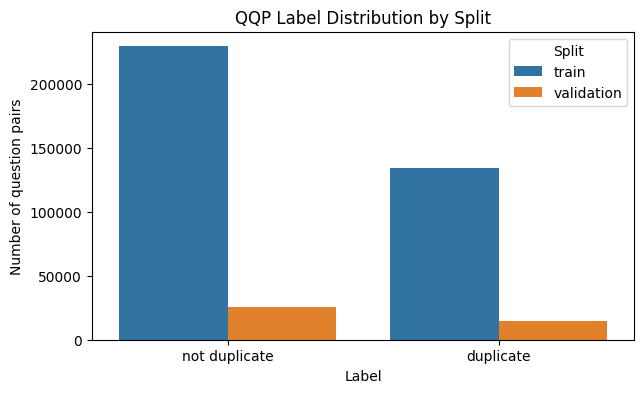

In [11]:
# I am visualising the label distribution
plot_data = pd.concat([
    train_preview[["label"]].assign(split="train"),
    eval_preview[["label"]].assign(split="validation")
], ignore_index=True)

plot_data["label_name"] = plot_data["label"].map(label_names)

plt.figure(figsize=(7, 4))
sns.countplot(data=plot_data, x="label_name", hue="split")
plt.title("QQP Label Distribution by Split")
plt.xlabel("Label")
plt.ylabel("Number of question pairs")
plt.legend(title="Split")
plt.show()


## Task 1 and Task 2:

The implementation of Task 1 and Task 2 mainly follows the NLTK preprocessing techniques from Practical Week 7 solutions that we have done in lab tutorial, including sentence tokenization, word tokenization, POS tagging, stemming, bigram extraction, and frequency counting. I adapted these techniques to the QQP dataset and the specific assignment requirements, such as processing question1 and question2 separately, using Universal POS tags, normalizing bigram frequencies, and avoiding bigrams across sentence boundaries.

### Task 1. What is the top-5 common NOUN in the question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 common NOUN in the questions. To find the part of speech, use NLTK's "Universal" tag set. You may need to use NLTK's `sent_tokenize` and `word_tokenize` to get words. The function returns a list that is descendingly sorted according to freqency, e.g. [(noun1, 22), (noun2, 10), ...].
<!-- To produce the correct results, the function must do this.  -->
Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use NLTK's part of speech tagger, using the "Universal" tagset.
- Use NLTK's `pos_tag_sents` instead of `pos_tag`.

Marking Criteria: 
- 2.5 marks for the correct codes and results of each column, namely question1 and question2 columns.




So regarding the implementation of task 1, this code cell extracts nouns from the training questions using NLP tokenization and part-of-speech tagging, then identifies and prints the five most common nouns in `question1` and `question2`. So as I have asked the tutor, we will only need to return top-5 common noun in the questions in the training set (q1_tr and q2_tr).


In [13]:
# I am defining a function to extract the top 5 most common nouns from a list of questions
def top_5_common_nouns(questions):
    text = " ".join(question for question in questions if isinstance(question, str))  # Combine all valid text questions into one large string
    sentences = sent_tokenize(text) # Split the combined text into sentences for better POS tagging context
    tokenized_sentences = [word_tokenize(sentence) for sentence in sentences]  # Tokenize each sentence into individual words for POS tagging
    tagged_sentences = nltk.pos_tag_sents(tokenized_sentences, tagset="universal") # Perform POS tagging on the tokenized sentences using the universal tagset for consistency

    nouns = [token for sentence in tagged_sentences for token, tag in sentence if tag == "NOUN"]  # Extract tokens and words that are tagged as NOUN
    noun_counts = Counter(nouns) # Count the frequency of each noun using Counter
    return noun_counts.most_common(5) # Return the 5 most common nouns and their counts as a list of tuples (noun, count)

So I will only do this task with the training set!

In [14]:
# I am extracting and printing the top 5 most common nouns in question1 and question2 of the training set only (I verified with tutor Abid about this requirement)
q1_top_5_nouns = top_5_common_nouns(q1_tr)
q2_top_5_nouns = top_5_common_nouns(q2_tr)

In [15]:
# I am printing the top 5 most common nouns in question1 and question2 of the training set only (I verified with tutor Abid about this requirement)
print("Top-5 common NOUN in question1:", q1_top_5_nouns)
print("Top-5 common NOUN in question2:", q2_top_5_nouns)

Top-5 common NOUN in question1: [('India', 11998), ('people', 11342), ('way', 7622), ('Quora', 7594), ('difference', 6641)]
Top-5 common NOUN in question2: [('India', 12804), ('people', 12094), ('way', 8529), ('Quora', 7889), ('life', 7098)]


### Task 2. What are the top-5 common stem 2-grams and non-stem 2-grams for question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 most frequent 2-grams (bigrams) of stemmed and non-stemmed tokens along with their normalized frequency from the question1 and question2 columns of the QQP dataset. The output should be in descending order of frequency, **with frequencies normalized by the total number of bigrams (rounded to 4 decimal places)**, e.g., `[(('what', 'is'), 0.0105), (('what', 'are'), 0.0053), ...]`.

<!-- To produce the correct results, the function must do this: -->

Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's Porter stemmer to get the root words.
- Round normalized frequency to 4 precision after the decimal point.
- When computing bigrams, do not consider words that are in different sentences. For example, if we have this text: `Sentence 1. And sentence 2.` the bigrams are: `('Sentence','1'), ('1','.'), ('.','And'), ('And','sentence')`, etc. Note that the following would not be a valid bigram, since the punctuation mark and the word "And" are in different sentences: `('.','And')`.

Marking Criteria: 
- 2.5 marks for the correct codes and restuls of each column, namely question1 and question2 columns.

So in this task 2, I would do every of my code in one code cell with code comments, so it would make easier to mark and see my code flow.


I am defining a function that identifies the 5 most common bigrams, or two-word combinations, from a collection of questions, as the requirement of assignment task 2. 

It first combines all valid text entries, tokenizes them into lowercase words, and optionally applies stemming using PorterStemmer to reduce words to their root forms. Then, it will generate bigrams for each sentence, counts their frequencies using Counter, and returns the top 5 most frequent bigrams along with their normalized frequencies. The analysis is performed separately for question1 and question2, both with and without stemming, so that we can observe the comparison of common phrase patterns and the effect of stemming on textual similarity analysis.

In [18]:
# Define a function to find the top 5 most common bigrams (2-word combinations)
def top_5_common_bigrams(questions, stem=False):
    stemmer = PorterStemmer() # Initialize the Porter stemmer for optional word stemming
    text = " ".join(question for question in questions if isinstance(question, str)) # Combine all valid text questions into 1 single large text string
    sentences = sent_tokenize(text) # Split the combined text into sentences for better bigram extraction context
    all_bigrams = [] # Initialize an empty list to store all bigrams from all sentences

    for sentence in sentences: # Iterate through each sentence to extract bigrams
        tokens = [token.lower() for token in word_tokenize(sentence)] # Tokenize the sentence into individual words and convert to lowercase for normalization
        # If stemming is enabled, apply the Porter stemmer to each token before extracting bigrams
        if stem:
            tokens = [stemmer.stem(token) for token in tokens] # Apply stemming to each token if the stem parameter is True
        # Extract bigrams from the tokenized sentence and store them   
        all_bigrams.extend(bigrams(tokens))

    # Calculate the total number of bigrams extracted across all sentences for frequency calculation
    total_bigrams = len(all_bigrams)
    if total_bigrams == 0:
        return []

    bigram_counts = Counter(all_bigrams) # Count the frequency of each bigram using Counter
    return [(bigram, round(count / total_bigrams, 4)) for bigram, count in bigram_counts.most_common(5)] # Return the 5 most common bigrams and their relative (normalized) frequencies as a list of tuples (bigram, frequency)

In [19]:
# I am extracting the top 5 most common bigrams (2-word combinations) in question1 of the training set, both with and without stemming, and printing the results
q1_non_stem_bigrams = top_5_common_bigrams(q1_tr, stem=False)
q1_stem_bigrams = top_5_common_bigrams(q1_tr, stem=True)

# I am extracting the top 5 most common bigrams (2-word combinations) in question2 of the training set, both with and without stemming, and printing the results
q2_non_stem_bigrams = top_5_common_bigrams(q2_tr, stem=False)
q2_stem_bigrams = top_5_common_bigrams(q2_tr, stem=True)

In [20]:
# I am printing the results
print("Top-5 non-stem 2-grams in question1:", q1_non_stem_bigrams)
print("Top-5 stem 2-grams in question1:", q1_stem_bigrams)
print("Top-5 non-stem 2-grams in question2:", q2_non_stem_bigrams)
print("Top-5 stem 2-grams in question2:", q2_stem_bigrams)

Top-5 non-stem 2-grams in question1: [(('what', 'is'), 0.0128), (('is', 'the'), 0.0112), (('what', 'are'), 0.0102), (('how', 'do'), 0.0084), (('can', 'i'), 0.0067)]
Top-5 stem 2-grams in question1: [(('what', 'is'), 0.0128), (('is', 'the'), 0.0112), (('what', 'are'), 0.0102), (('how', 'do'), 0.0084), (('can', 'i'), 0.0067)]
Top-5 non-stem 2-grams in question2: [(('what', 'is'), 0.0123), (('is', 'the'), 0.0108), (('what', 'are'), 0.0098), (('how', 'do'), 0.0085), (('can', 'i'), 0.0068)]
Top-5 stem 2-grams in question2: [(('what', 'is'), 0.0123), (('is', 'the'), 0.0108), (('what', 'are'), 0.0098), (('how', 'do'), 0.0085), (('can', 'i'), 0.0068)]


### Task 3. Naïve Bayes Classifier (5.5 marks)

The QQR dataset contains pairs of questions with labels indicating whether the two questions are semantically duplicate (1) or not (0).

1. Using a Bag-of-Words representation, train a Naïve Bayes classifier to predict duplicates. (2 marks)

1. Report accuracy, precision, and recall on the test set. (1.5 marks)

1. Inspect your confusion matrix. Identify one type of error (false positive or false negative) that dominates. Suggest a possible reason for this pattern based on the dataset. (2 mark)

The code cell below is provided by default, so basically it loads the QQP dataset and creates smaller fixed training and validation subsets to reduce computing cost while keeping model comparisons fair. We will use 1000 samples from the training set and 100 samples from the validation set => smaller subsets for faster and fair model experimentation.

I will use same subsets of data that the assignment requires, I will continue form this code cell.

In [26]:
# From now on, you are allowed to use a subset of the dataset which requires less computing resources.
# Note that you have to use the same subset for the following coding tasks, which ensure fairness when comparing performance across different models.

Ntrain = 1000
Ntest = 100
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"].select(range(Ntrain))
eval_ds  = ds["validation"].select(range(Ntest))

I am implementing the set up for BoW representations, so basically this code cell below combines each pair of questions into a single text input, prepares the corresponding labels for training and testing, and prints the number of examples used for the Naive Bayes Bag-of-Words model.

In [27]:
# I am preparing Bag-of-Words inputs for Naive Bayes
train_texts_nb = [
    f"{q1} {q2}" for q1, q2 in zip(train_ds["question1"], train_ds["question2"])  # Combine question1 and question2 into a single string for each example in the training set to create the input texts for the Naive Bayes model
]
test_texts_nb = [
    f"{q1} {q2}" for q1, q2 in zip(eval_ds["question1"], eval_ds["question2"]) # Combine question1 and question2 into a single string for each example in the validation set to create the input texts for the Naive Bayes model
]


# I am converting the labels for the training and test sets into numpy arrays for use in model training and evaluation
y_train_nb = np.array(train_ds["label"])
y_test_nb = np.array(eval_ds["label"])

# I am printing the number of training and test examples being used for the Naive Bayes model
print(f"Training examples: {len(train_texts_nb)}")
print(f"Test examples: {len(test_texts_nb)}")


Training examples: 1000
Test examples: 100


Here, I am going to build and train my Naive Bayes model with the multinomial NB algorithm using BoW representation

In [28]:
# I am training a Bag-of-Words Naive Bayes classifier
# I am creating a pipeline that combines CountVectorizer for converting text to a bag-of-words representation and MultinomialNB for performing Naive Bayes classification
nb_model = Pipeline([
    ("vectorizer", CountVectorizer()), # Convert text to a bag-of-words representation using CountVectorizer
    ("classifier", MultinomialNB()) # Use Multinomial Naive Bayes for classification
])

nb_model.fit(train_texts_nb, y_train_nb) # Start training the model using the training texts and their corresponding labels
y_pred_nb = nb_model.predict(test_texts_nb) # After training, use the model to predict labels for the test texts and store the predictions in y_pred_nb


This step is quite straightforward, cause I am going to printing out the results for the trained NB model classifier above "nb_model".
So basically this code cell evaluates the Naive Bayes model by calculating accuracy, precision, and recall on the test set, then generates and visualizes a confusion matrix to compare predicted and actual labels.

I will wrap and include all of my evaluation metrics code in this code cell so that you can see my code and all the evaluation metrics easier in one run. I can do it separately, but I think it would make the markers confused with too many different code cells created.

In [29]:
# After running the training code cell above, I am doing report evaluation metrics and confusion matrix.
# I am calculating the accuracy, precision, recall, and F1-score for the Naive Bayes model's predictions on the test set
accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)
precision_nb = precision_score(y_test_nb, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test_nb, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test_nb, y_pred_nb, zero_division=0)

# I am printing the evaluation metrics for the Naive Bayes model on the test set
print("Naive Bayes metrics on test set:")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-score: {f1_nb:.4f}")

Naive Bayes metrics on test set:
Accuracy: 0.6600
Precision: 0.4286
Recall: 0.4000
F1-score: 0.4138


In [30]:
# I am printing the classification report for the Naive Bayes model's predictions on the test set
print("Classification report:")
print(classification_report(
    y_test_nb,
    y_pred_nb,
    target_names=["not duplicate", "duplicate"],
    zero_division=0
))

Classification report:
               precision    recall  f1-score   support

not duplicate       0.75      0.77      0.76        70
    duplicate       0.43      0.40      0.41        30

     accuracy                           0.66       100
    macro avg       0.59      0.59      0.59       100
 weighted avg       0.65      0.66      0.66       100



Confusion matrix:


,predicted not duplicate,predicted duplicate
actual not duplicate,54,16
actual duplicate,18,12


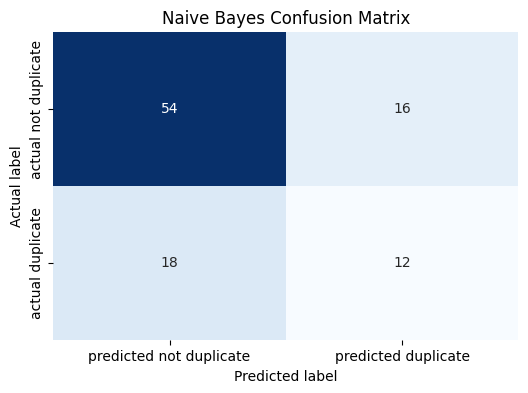

In [31]:
# I am computing the confusion matrix for the Naive Bayes model's predictions on the test set and visualizing it as a heatmap using seaborn
cm_nb = confusion_matrix(y_test_nb, y_pred_nb, labels=[0, 1])
cm_nb_df = pd.DataFrame(
    cm_nb,
    index=["actual not duplicate", "actual duplicate"],
    columns=["predicted not duplicate", "predicted duplicate"]
)

print("Confusion matrix:")
display(cm_nb_df)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Naive Bayes Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

According to the assignment requirements of task 3, I am going to inspect the dominant error type of the results of this model classifier. So I use ChatGPT to help me write the if-else condition code here in this task. However, I still have my own deeper analysis later, not only the error reason in this condition statement. This code is only for observation purpose.

The prompt I used: "Generate Python code that inspects a confusion matrix (cm_nb) for a Naive Bayes QQP classifier, compares false positives and false negatives, identifies the dominant error type, and prints an explanation based on Bag-of-Words limitations."

In [32]:
# I am going to inspect the dominant error type
false_positives_nb = cm_nb[0, 1]
false_negatives_nb = cm_nb[1, 0]

print(f"False positives: {false_positives_nb}")
print(f"False negatives: {false_negatives_nb}")

if false_positives_nb > false_negatives_nb:
    dominant_error_nb = "false positives"
    error_reason_nb = (
        "False positives dominate. A likely reason is that some non-duplicate QQP "
        "question pairs share many keywords, so a Bag-of-Words Naive Bayes model may "
        "overestimate similarity even when the meanings differ."
    )
elif false_negatives_nb > false_positives_nb:
    dominant_error_nb = "false negatives"
    error_reason_nb = (
        "False negatives dominate. A likely reason is that some duplicate QQP "
        "question pairs use different wording, so a Bag-of-Words Naive Bayes model may "
        "miss semantic similarity when exact word overlap is low."
    )
else:
    dominant_error_nb = "equal false positives and false negatives"
    error_reason_nb = (
        "False positives and false negatives are equal. This reflects a limitation of "
        "Bag-of-Words features: they count token overlap but do not deeply model meaning."
    )

print(f"Dominant error type: {dominant_error_nb}")
print("Error analysis:", error_reason_nb)


False positives: 16
False negatives: 18
Dominant error type: false negatives
Error analysis: False negatives dominate. A likely reason is that some duplicate QQP question pairs use different wording, so a Bag-of-Words Naive Bayes model may miss semantic similarity when exact word overlap is low.


Deeper Analysis on the result:

From the confusion matrix, the Naive Bayes model correctly predicts 54 non-duplicate pairs and 12 duplicate pairs. It makes 16 false positive errors and 18 false negative errors, so false negatives are the slightly dominant error type. But actually it is only a small difference.

This means the model more often predicts "not duplicate" for question pairs that are actually duplicates. One likely reason is that the model uses a Bag-of-Words representation, which mainly depends on word counts and lexical overlap. In the QQP dataset, duplicate questions can ask the same thing using different wording, so they may not share many exact tokens. Because Bag-of-Words does not capture deeper semantic similarity very well, the model can miss these duplicate pairs.

The reduced dataset is also somewhat imbalanced and I think it might cause to the bad result of the model classifier performance after training. The training set has 648 non-duplicate pairs and 352 duplicate pairs, while the test set has 70 non-duplicate pairs and 30 duplicate pairs. This class imbalance may also make the model more likely to predict the majority class, which contributes to false negatives for the duplicate class.



### Task 4. Siamese Neural Network (7 marks)

You now want to learn semantic similarity directly from the question pairs.

1. Design a Siamese Neural Network with two identical LSTM encoders that embed each question. (3 marks)

1. Use cosine similarity to classify duplicates, and report accuracy and F1-score. (2 marks)

1. Compare your Siamese model to your Naïve Bayes model. Which one handles imbalanced errors (precision vs. recall) better in your results, and why do you think that is? (2 marks)

**Note: Use the same reduced training and test subsets that you selected/used for Task 3.**

This Task 4 implementation follows the Siamese-network style from Practical 10.2. Each question pair is tokenized in the same way, then both questions pass through the same LSTM encoder with shared weights. The assignment requires cosine similarity, so I use cosine embedding loss and cosine-threshold classification instead of Practical 10.2's L1-distance classifier.

Shout out to all tutors for your guidance at practical labs.

BERT is used only as a tokenizer here. The classifier itself is still a Siamese LSTM model.


First, I set the random seeds and hyperparameters. The Siamese LSTM is trained on the same 1000 training examples used in Task 3. An additional 200 examples from the QQP training split are used only to choose the cosine-similarity threshold. The final test set remains `eval_ds`, the same 100-example validation subset used as the test set in Task 3.


In [49]:
# I am setting up the configuration for the Siamese LSTM model, including random seeds for reproducibility, model hyperparameters, and device configuration for training on GPU if available.
SIAMESE_SEED = 42
MAX_LEN = 30
EMBED_SIZE = 128
LSTM_UNITS = 64
BATCH_SIZE = 32
N_EPOCHS = 20
LEARNING_RATE = 1e-3
DROPOUT = 0.3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SIAMESE_SEED)
torch.manual_seed(SIAMESE_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SIAMESE_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# I am training the Siamese model on the same 1000-example training subset used in Task 3.
# The extra 200 examples are used only for selecting the cosine-similarity threshold.
siamese_train_ds = train_ds
siamese_val_ds = ds["train"].select(range(Ntrain, Ntrain + 200))
siamese_test_ds = eval_ds

# printing out the details
print("Device:", DEVICE)
print(f"Siamese training examples: {len(siamese_train_ds)}")
print(f"Siamese threshold-validation examples: {len(siamese_val_ds)}")
print(f"Siamese test examples: {len(siamese_test_ds)}")
print("Training label distribution:", Counter(siamese_train_ds["label"]))
print("Validation label distribution:", Counter(siamese_val_ds["label"]))
print("Test label distribution:", Counter(siamese_test_ds["label"]))


Device: cuda
Siamese training examples: 1000
Siamese threshold-validation examples: 200
Siamese test examples: 100
Training label distribution: Counter({0: 648, 1: 352})
Validation label distribution: Counter({0: 128, 1: 72})
Test label distribution: Counter({0: 70, 1: 30})


This code is used to initialize the pretrained "bert-base-uncased" tokenizer that we used at lab week 10 for Siamese LSTM model using HF's "BertTokenizer".

In [50]:
# I will be using the BERT tokenizer for the Siamese LSTM model, and I am printing the tokenizer name, vocabulary size, padding token ID, and maximum sequence length.
SIAMESE_TOKENIZER_NAME = "bert-base-uncased"
SIAMESE_TOKENIZER = BertTokenizer.from_pretrained(SIAMESE_TOKENIZER_NAME)
VOCAB_SIZE = SIAMESE_TOKENIZER.vocab_size
PAD_IDX = SIAMESE_TOKENIZER.pad_token_id

# I am printing out the tokenizer details
print("Siamese tokenizer:", SIAMESE_TOKENIZER_NAME)
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Padding token ID: {PAD_IDX}")
print(f"Maximum sequence length: {MAX_LEN}")


Siamese tokenizer: bert-base-uncased
Vocabulary size: 30522
Padding token ID: 0
Maximum sequence length: 30


This code is used to define a custom Pytorch Dataset class for preparing question pairs for my Siamese LSTM model.

In [51]:
# I am defining a custom PyTorch Dataset class for the Siamese LSTM model that takes in a Hugging Face dataset, a tokenizer, and a maximum sequence length, 
# and implements the necessary methods to encode the questions and return the input IDs, attention masks, and labels for each example in the dataset.
class SiameseDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len):
        self.sents1 = list(hf_dataset["question1"])
        self.sents2 = list(hf_dataset["question2"])
        self.labels = np.array(hf_dataset["label"], dtype=np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def encode_question(self, question):
        encoding = self.tokenizer(
            str(question),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
        ids = encoding["input_ids"].squeeze(0)
        length = encoding["attention_mask"].sum().long().clamp(min=1)
        return ids, length

    def __getitem__(self, idx):
        ids1, len1 = self.encode_question(self.sents1[idx])
        ids2, len2 = self.encode_question(self.sents2[idx])

        return {
            "ids1": ids1,
            "len1": len1,
            "ids2": ids2,
            "len2": len2,
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32)
        }

In [52]:
# I am creating a PyTorch Generator with the defined random seed for reproducibility when shuffling the training data in the DataLoader.
generator = torch.Generator()
generator.manual_seed(SIAMESE_SEED)

In [53]:
# I am creating the Siamese training, validation, and test datasets
train_dataset = SiameseDataset(siamese_train_ds, SIAMESE_TOKENIZER, MAX_LEN)
val_dataset = SiameseDataset(siamese_val_ds, SIAMESE_TOKENIZER, MAX_LEN)
test_dataset = SiameseDataset(siamese_test_ds, SIAMESE_TOKENIZER, MAX_LEN)

In [54]:
# I am creating DataLoader objects for the training, validation, and test datasets, with shuffling enabled for the training set and disabled for the validation and test sets, 
# using the defined batch size and generator for reproducibility.
train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_iterator = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_iterator = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [56]:
# printing out the number of batches in the training, validation, and test DataLoaders
print("Train batches:", len(train_iterator))
print("Validation batches:", len(val_iterator))
print("Test batches:", len(test_iterator))

Train batches: 32
Validation batches: 7
Test batches: 4


My model keeps the Practical 10.2 `forward_once()` structure. Both questions use the same embedding layer and the same LSTM, so the two encoders are identical and shared.


My Siamese LSTM neural network will process two questions through shared embedding and bidirectional LSTM layers to generate comparable vector representations for duplicate-question similarity analysis.

In [58]:
# I am defining the architecture of the Siamese LSTM model, which consists of an embedding layer, a bidirectional LSTM layer, and a dropout layer. 
# The model encodes two input questions separately and returns their encoded representations.
class SiameseNetwork(nn.Module):
    def __init__(self, vocab_size, embed_size, lstm_units, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_size,
            lstm_units,
            bidirectional=True,
            batch_first=True,
            num_layers=1
        )
        self.dropout = nn.Dropout(dropout)

    # The forward_once method encodes a single question by passing its input IDs through the embedding layer, packing the sequence for the LSTM, 
    # and concatenating the final hidden states from both directions of the bidirectional LSTM to produce a fixed-size representation of the question.
    def forward_once(self, ids, lengths):
        embedded = self.embedding(ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        hidden_out = torch.cat((h_n[0, :, :], h_n[1, :, :]), dim=1)
        return self.dropout(hidden_out)

    # The forward method takes in the input IDs and lengths for two questions, encodes each question separately using the forward_once method,
    # and returns their encoded representations as a tuple.
    def forward(self, ids1, len1, ids2, len2):
        encoded1 = self.forward_once(ids1, len1)
        encoded2 = self.forward_once(ids2, len2)
        return encoded1, encoded2


Here, I start training my Siamese LSTM model using cosine embedding loss, where the network learns to generate similar embeddings for duplicate questions and dissimilar embeddings for non-duplicate questions while monitoring both training and validation loss across epochs.

Using cosine similarity to make duplicate question embeddings closer and non-duplicate question embeddings less similar. After training, I compute cosine similarity directly between the two question embeddings and classify pairs using a selected threshold.

In [59]:
# I am defining the training and evaluation functions for the Siamese LSTM model.
def train_siamese_epoch(model, iterator, optimizer, criterion, device):
    epoch_loss = 0.0
    model.train()

    for batch in iterator: # Iterate through each batch of data in the training DataLoader
        ids1 = batch["ids1"].to(device)
        len1 = batch["len1"].to(device)
        ids2 = batch["ids2"].to(device)
        len2 = batch["len2"].to(device)
        labels = batch["labels"].to(device)
        cosine_targets = labels * 2 - 1

        optimizer.zero_grad()
        encoded1, encoded2 = model(ids1, len1, ids2, len2)
        loss = criterion(encoded1, encoded2, cosine_targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item() * labels.size(0)

    return epoch_loss / len(iterator.dataset) # Return the average loss for the epoch by dividing the total loss by the number of examples in the dataset

In [60]:
# The evaluate_siamese_epoch function evaluates the model on a given dataset by iterating through the batches, 
# encoding the questions, calculating the loss using the cosine embedding loss criterion, and returning the average loss for the epoch.
def evaluate_siamese_epoch(model, iterator, criterion, device):
    epoch_loss = 0.0
    model.eval()

    with torch.no_grad(): # Disable gradient calculation for evaluation to save memory and computation
        for batch in iterator: # Iterate through each batch of data in the validation/test DataLoader
            ids1 = batch["ids1"].to(device)
            len1 = batch["len1"].to(device)
            ids2 = batch["ids2"].to(device)
            len2 = batch["len2"].to(device)
            labels = batch["labels"].to(device)
            cosine_targets = labels * 2 - 1

            encoded1, encoded2 = model(ids1, len1, ids2, len2)
            loss = criterion(encoded1, encoded2, cosine_targets)
            epoch_loss += loss.item() * labels.size(0)

    return epoch_loss / len(iterator.dataset) # Return the average loss for the epoch by dividing the total loss by the number of examples in the dataset

In [65]:
# I am initializing the Siamese LSTM model with the defined hyperparameters and moving it to the configured device (my GPU on my local machine),
# and setting up the cosine embedding loss criterion and Adam optimizer for training the model.
siamese_model = SiameseNetwork(
    VOCAB_SIZE,
    EMBED_SIZE,
    LSTM_UNITS,
    DROPOUT,
    PAD_IDX
).to(DEVICE)

# I am defining the loss function as cosine embedding loss
# and setting up the Adam optimizer with the specified learning rate above to optimize the model parameters during training.
criterion = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(siamese_model.parameters(), lr=LEARNING_RATE)

In [66]:
# I am training the Siamese LSTM model for the specified number of epochs, and after each epoch, I am evaluating the model on the validation set and printing the training and validation losses for that epoch.
print("Training Siamese LSTM...")
for epoch in range(N_EPOCHS):
    train_loss = train_siamese_epoch(siamese_model, train_iterator, optimizer, criterion, DEVICE)
    val_loss = evaluate_siamese_epoch(siamese_model, val_iterator, criterion, DEVICE)
    print(f"Epoch: {epoch + 1:02d} | Siamese Train Loss: {train_loss:.4f} | Siamese Val. Loss: {val_loss:.4f}")

Training Siamese LSTM...
Epoch: 01 | Siamese Train Loss: 0.4400 | Siamese Val. Loss: 0.3850
Epoch: 02 | Siamese Train Loss: 0.3591 | Siamese Val. Loss: 0.3583
Epoch: 03 | Siamese Train Loss: 0.3292 | Siamese Val. Loss: 0.3501
Epoch: 04 | Siamese Train Loss: 0.2996 | Siamese Val. Loss: 0.3544
Epoch: 05 | Siamese Train Loss: 0.2824 | Siamese Val. Loss: 0.3487
Epoch: 06 | Siamese Train Loss: 0.2668 | Siamese Val. Loss: 0.3422
Epoch: 07 | Siamese Train Loss: 0.2517 | Siamese Val. Loss: 0.3410
Epoch: 08 | Siamese Train Loss: 0.2334 | Siamese Val. Loss: 0.3435
Epoch: 09 | Siamese Train Loss: 0.2241 | Siamese Val. Loss: 0.3394
Epoch: 10 | Siamese Train Loss: 0.2080 | Siamese Val. Loss: 0.3460
Epoch: 11 | Siamese Train Loss: 0.1999 | Siamese Val. Loss: 0.3456
Epoch: 12 | Siamese Train Loss: 0.1835 | Siamese Val. Loss: 0.3521
Epoch: 13 | Siamese Train Loss: 0.1791 | Siamese Val. Loss: 0.3547
Epoch: 14 | Siamese Train Loss: 0.1676 | Siamese Val. Loss: 0.3613
Epoch: 15 | Siamese Train Loss: 0.159

This code uses cosine similarity to compare the two question embeddings produced by the Siamese LSTM, selects the best classification threshold based on validation F1-score, then evaluates the model on the test set using accuracy, precision, recall, F1-score, and a confusion matrix heatmap.

In [77]:
# I am collecting cosine similarity scores and true labels from a DataLoader
def collect_siamese_scores(model, iterator, device):
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in iterator:
            # Move question pair tensors to my GPU device
            ids1 = batch["ids1"].to(device)
            len1 = batch["len1"].to(device)
            ids2 = batch["ids2"].to(device)
            len2 = batch["len2"].to(device)

            # Encode both questions with the shared Siamese LSTM
            encoded1, encoded2 = model(ids1, len1, ids2, len2)

            # Compute cosine similarity between the two embeddings
            similarities = nn.functional.cosine_similarity(encoded1, encoded2)

            # Store scores and labels for later evaluation
            all_scores.extend(similarities.cpu().numpy())
            all_labels.extend(batch["labels"].numpy().astype(int))

    return np.array(all_scores), np.array(all_labels)


In [78]:
# Use validation scores for threshold selection and test scores for final evaluation
val_scores_siamese, y_val_siamese = collect_siamese_scores(siamese_model, val_iterator, DEVICE)
test_scores_siamese, y_test_siamese = collect_siamese_scores(siamese_model, test_iterator, DEVICE)

In [79]:
# Try thresholds across the cosine similarity range
threshold_candidates = np.linspace(-1.0, 1.0, 201)
best_threshold = 0.0
best_val_f1 = -1.0
best_val_gap = float("inf")

# Select the threshold with the best validation F1-score
for threshold in threshold_candidates:
    val_predictions = (val_scores_siamese >= threshold).astype(int)
    val_f1 = f1_score(y_val_siamese, val_predictions, zero_division=0)
    val_precision = precision_score(y_val_siamese, val_predictions, zero_division=0)
    val_recall = recall_score(y_val_siamese, val_predictions, zero_division=0)
    val_gap = abs(val_precision - val_recall)

    # If F1 ties, choose the threshold with better precision-recall balance
    if val_f1 > best_val_f1 or (np.isclose(val_f1, best_val_f1) and val_gap < best_val_gap):
        best_val_f1 = val_f1
        best_val_gap = val_gap
        best_threshold = threshold

In [80]:
# Convert test cosine scores into duplicate/not-duplicate predictions
y_pred_siamese = (test_scores_siamese >= best_threshold).astype(int)

In [81]:
# Calculate final test metrics
accuracy_siamese = accuracy_score(y_test_siamese, y_pred_siamese)
precision_siamese = precision_score(y_test_siamese, y_pred_siamese, zero_division=0)
recall_siamese = recall_score(y_test_siamese, y_pred_siamese, zero_division=0)
f1_siamese = f1_score(y_test_siamese, y_pred_siamese, zero_division=0)
cm_siamese = confusion_matrix(y_test_siamese, y_pred_siamese, labels=[0, 1])

In [82]:
# Print selected threshold and evaluation results
print(f"Selected cosine threshold: {best_threshold:.2f}")
print(f"Validation F1 at selected threshold: {best_val_f1:.4f}")

print("Siamese LSTM metrics on test set:")
print(f"Accuracy: {accuracy_siamese:.4f}")
print(f"Precision: {precision_siamese:.4f}")
print(f"Recall: {recall_siamese:.4f}")
print(f"F1-score: {f1_siamese:.4f}")

Selected cosine threshold: 0.48
Validation F1 at selected threshold: 0.6082
Siamese LSTM metrics on test set:
Accuracy: 0.6000
Precision: 0.3810
Recall: 0.5333
F1-score: 0.4444


Siamese confusion matrix:


,predicted not duplicate,predicted duplicate
actual not duplicate,44,26
actual duplicate,14,16


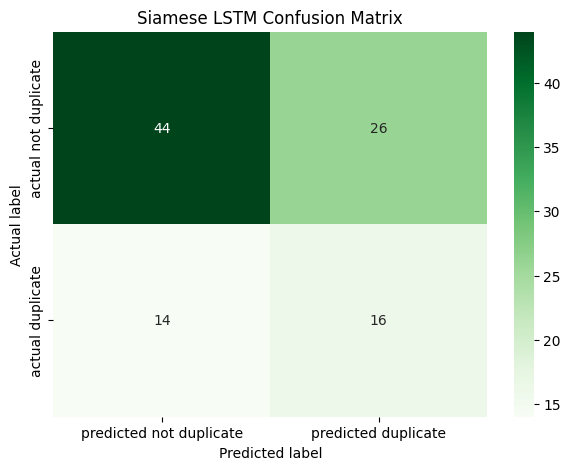

In [85]:
# Build a confusion matrix table
cm_siamese_df = pd.DataFrame(
    cm_siamese,
    index=["actual not duplicate", "actual duplicate"],
    columns=["predicted not duplicate", "predicted duplicate"]
)

print("Siamese confusion matrix:")
display(cm_siamese_df)

# Plot the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_siamese_df, annot=True, fmt="d", cmap="Greens")
plt.title("Siamese LSTM Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

Finally, I compare the Siamese LSTM with the Naive Bayes model from Task 3 using the actual precision and recall values. The smaller precision-recall gap is treated as the better balance between the two error types.


This is AI-generated code, so I asked Claude to help me generate a code cell to compare the evaluation performance of the Naive Bayes and Siamese LSTM models by calculating accuracy, precision, recall, F1-score, and the precision-recall gap, then automatically generate an interpretation explaining which model achieves a better balance between duplicate and non-duplicate predictions.

However, I still also have my own deeper analysis on the comparison and the produced results, so this code is just to observe the overall results in comparison between two trained models.


In [86]:
# I am creating a comparison table of the evaluation metrics for both the Naive Bayes and Siamese LSTM models, 
# including accuracy, precision, recall, F1-score, and the absolute gap between precision and recall to assess the balance of predictions.
f1_nb = f1_score(y_test_nb, y_pred_nb, zero_division=0)

comparison_df = pd.DataFrame([
    {
        "model": "Naive Bayes",
        "accuracy": accuracy_nb,
        "precision": precision_nb,
        "recall": recall_nb,
        "f1": f1_nb,
        "precision_recall_gap": abs(precision_nb - recall_nb)
    },
    {
        "model": "Siamese LSTM",
        "accuracy": accuracy_siamese,
        "precision": precision_siamese,
        "recall": recall_siamese,
        "f1": f1_siamese,
        "precision_recall_gap": abs(precision_siamese - recall_siamese)
    }
]).round(4)

display(comparison_df)

,model,accuracy,precision,recall,f1,precision_recall_gap
0,Naive Bayes,0.66,0.4286,0.4000,0.4138,0.0286
1,Siamese LSTM,0.60,0.3810,0.5333,0.4444,0.1524


In [87]:
# I am comparing the precision-recall balance of the Naive Bayes and Siamese LSTM models by looking at the absolute gap between their precision and recall values.
nb_gap = comparison_df.loc[comparison_df["model"] == "Naive Bayes", "precision_recall_gap"].iloc[0]
siamese_gap = comparison_df.loc[comparison_df["model"] == "Siamese LSTM", "precision_recall_gap"].iloc[0]
gap_difference = abs(nb_gap - siamese_gap)

if gap_difference <= 0.02:
    comparison_text = (
        "Both models show similar precision-recall balance, but they make errors for "
        "different reasons. Naive Bayes relies on word overlap, while the Siamese model "
        "tries to learn question representations from limited data."
    )
elif siamese_gap < nb_gap:
    comparison_text = (
        "The Siamese LSTM handles the precision-recall imbalance better because its gap "
        "is smaller. This suggests that learning paired question representations with an "
        "LSTM and cosine similarity helped balance duplicate and non-duplicate predictions."
    )
else:
    comparison_text = (
        "Naive Bayes handles the precision-recall imbalance better in these results. The "
        "Siamese LSTM may require more data to learn reliable semantic similarity, because "
        "it is trained from scratch on only 1000 examples."
    )

print("Comparison:", comparison_text)


Comparison: Naive Bayes handles the precision-recall imbalance better in these results. The Siamese LSTM may require more data to learn reliable semantic similarity, because it is trained from scratch on only 1000 examples.


### Deeper Analysis on the Comparison

From the comparison table, Naive Bayes achieves accuracy `0.6600`, precision `0.4286`, recall `0.4000`, and F1-score `0.4138`. The Siamese LSTM achieves accuracy `0.6000`, precision `0.3810`, recall `0.5333`, and F1-score `0.4444`. As we can see that there is a quite significant difference gap between the two models.

For the specific question of precision-recall imbalance, Naive Bayes model performs better because its precision and recall are much closer together. Its precision-recall gap is only `0.0286`, while the Siamese LSTM has a larger gap of `0.1524`. This means Naive Bayes is more balanced between avoiding false duplicate predictions and finding real duplicate pairs.

However, the Siamese LSTM has a higher recall (`0.5333`) than Naive Bayes (`0.4000`) and also a slightly higher F1-score (`0.4444` compared with `0.4138`). This suggests that the Siamese model is better at identifying duplicate question pairs in overall, even though it sacrifices precision. In other words, it finds more true duplicates, but it also incorrectly predicts more non-duplicate pairs as duplicates.

This pattern is reasonable for the QQP dataset. Duplicate questions can be written with different wording, so a Bag-of-Words Naive Bayes model may miss them because it mainly depends on lexical overlap. The Siamese LSTM tries to learn semantic representations of each question and compares them with cosine similarity, which helps improve recall. However, because it is trained from scratch on only 1000 examples, so I think that its learned representations may not be stable enough to separate semantically related but non-duplicate questions, which lowers the precision score of the model.

Overall, Naive Bayes handles the precision-recall imbalance better in my results, because its precision and recall are more balanced. The Siamese LSTM performs better in terms of recall and F1-score, showing that it is more useful for detecting duplicates, but it would likely need more training data or stronger pretrained embeddings to improve precision.

Note: One possible reason Naive Bayes performs competitively, and has better precision-recall balance than the Siamese LSTM, is that the experiment uses a very small training subset of only 1000 examples. Naive Bayes is a simple machine learning model with strong assumptions, so it can work reasonably well with limited data, especially when word overlap is an important signal for duplicate questions.

While the Siamese LSTM has many more trainable parameters and needs more data to learn reliable semantic representations from scratch. So when we feed and pass in the model for training with only 1000 examples, so it may overfit patterns in the small training set or fail to learn enough general language knowledge. As a result, it improves recall by finding more duplicate pairs, but it also makes more false positive predictions, which lowers the precision score.

Therefore, Naive Bayes can outperform or appear more balanced than the LSTM in this small amount of data setting, not because it understands semantics better, but I think it is because of its simpler Bag-of-Words representation, which is more stable with limited training data.

Important note: 

I am using extra 200 QQP training examples only for threshold selection, my Siamese model is trained on the same 1000 samples as Task 3, and also the final test set is the same 100 samples as Task 3.

Task 4 DONE!

### Task 5. Transformer-Based Classifier (10 marks)

Instead of handcrafted features or LSTMs, you now fine-tune a pre-trained Transformer (e.g., BERT or RoBERTa, etc) for QQP.

1. Fine-tune the model for 3 epochs with learning rate 2e-5. (3 marks)

1. Report the accuracy, precision, recall, and F1-score. (2 marks)

1. Compare your Transformer results with your Siamese model. Did the Transformer improve both precision and recall, or mainly one? What does this suggest about how it captures question meaning? (2 marks)

1. Look at one example your Transformer misclassified. Write a short explanation of why the model might have made this mistake. (3 marks)

**Note: Use the same reduced training and test subsets that you selected/used for Task 3.**

As I can see that the Practical 10.2 introduces BERT tokenization, but Task 5 requires fine-tuning a pre-trained Transformer classifier. Therefore, this task uses Hugging Face's Trainer API to fine-tune `bert-base-uncased` directly on QQP question pairs.


In [115]:
# I am setting up the configuration for the Transformer-based model
TRANSFORMER_MODEL_NAME = "bert-base-uncased"
TRANSFORMER_EPOCHS = 3 # assignment requirement is only 3 epochs
TRANSFORMER_LEARNING_RATE = 2e-5
TRANSFORMER_BATCH_SIZE = 8

print("Transformer model:", TRANSFORMER_MODEL_NAME)
print(f"Training examples: {len(train_ds)}")
print(f"Test examples: {len(eval_ds)}")

Transformer model: bert-base-uncased
Training examples: 1000
Test examples: 100


In [116]:
# I am loading the BERT tokenizer for the specified transformer model to preprocess the input questions for the Transformer-based model.
TOKENIZER = BertTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

In [117]:
# I am defining a function to encode pairs of questions from the QQP dataset using the BERT tokenizer, 
# which will be applied to the training and evaluation datasets in a batched manner.
def encode_qqp_batch(batch):
    return TOKENIZER(
        batch["question1"],
        batch["question2"],
        truncation=True
    )

In [118]:
# I am applying the encoding function to the training and evaluation datasets using the map method, which processes the data in batches for efficiency.
tokenized_train_ds = train_ds.map(encode_qqp_batch, batched=True)
tokenized_eval_ds = eval_ds.map(encode_qqp_batch, batched=True)

In [122]:
# I am renaming the "label" column to "labels" in both the tokenized training and evaluation datasets, 
# as this is the expected format for the Hugging Face Trainer API when using a model for sequence classification.
if "label" in tokenized_train_ds.column_names:
    tokenized_train_ds = tokenized_train_ds.rename_column("label", "labels")
if "label" in tokenized_eval_ds.column_names:
    tokenized_eval_ds = tokenized_eval_ds.rename_column("label", "labels")

In [123]:
# I am identifying the columns to remove from the tokenized training and evaluation datasets, 
# which include the original "question1", "question2", and "idx" columns that are no longer needed after tokenization.
columns_to_remove_train = [
    column for column in ["question1", "question2", "idx"]
    if column in tokenized_train_ds.column_names
]
columns_to_remove_eval = [
    column for column in ["question1", "question2", "idx"]
    if column in tokenized_eval_ds.column_names
]

In [124]:
# I am removing the identified columns from the tokenized training and evaluation datasets to keep only the necessary input features and labels for model training and evaluation.
if columns_to_remove_train:
    tokenized_train_ds = tokenized_train_ds.remove_columns(columns_to_remove_train)
if columns_to_remove_eval:
    tokenized_eval_ds = tokenized_eval_ds.remove_columns(columns_to_remove_eval)

In [130]:
# I am creating a data collator that will dynamically pad the input sequences to the maximum length in each batch during training and evaluation of the Transformer-based model.
DATA_COLLATOR = DataCollatorWithPadding(tokenizer=TOKENIZER)

print("Tokenized training columns:", tokenized_train_ds.column_names)
print("Tokenized test columns:", tokenized_eval_ds.column_names)

Tokenized training columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Tokenized test columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


This code sets random seeds for reproducibility, loads a pre-trained Transformer model for binary sequence classification on the QQP duplicate-question task, and defines a custom evaluation function that computes accuracy, precision, recall, and F1-score from the model’s predictions during Hugging Face Trainer evaluation.


In [132]:
# I am setting random seeds for reproducibility
# ensuring that the same random initialization and data shuffling occur across runs.
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# I am loading the pre-trained BERT model for sequence classification, 
# specifying the number of output labels (duplicate vs not duplicate) to fine-tune it on the QQP dataset.
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=2
)

# I am defining a function to compute evaluation metrics (accuracy, precision, recall, F1-score) for the Transformer-based model's predictions on the test set,
# which will be used by the Hugging Face Trainer during evaluation.
def compute_transformer_metrics(eval_pred):
    logits = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0)
    }


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Here, I will start fine-tuning the model and handle the training loop and evaluation and logging based on the defined training arguments and datasets.

In [146]:
# I will start fine-tuning the Transformer-based model using the Hugging Face Trainer API, 
# which handles the training loop, evaluation, and logging based on the specified training arguments and datasets.
def train_transformer_classifier(model, train_dataset, eval_dataset):
    training_args = TrainingArguments(
        output_dir="./task5_bert_qqp",
        learning_rate=TRANSFORMER_LEARNING_RATE,
        per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,
        per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE,
        num_train_epochs=TRANSFORMER_EPOCHS,
        weight_decay=0.01,
        logging_strategy="epoch",
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=42,
        data_seed=42,
        do_train=True,
        do_eval=True
    )
    # I am initializing the Trainer with the model, training arguments, datasets, data collator, tokenizer for processing, and the metric computation function defined above.
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=DATA_COLLATOR,
        processing_class=TOKENIZER,
        compute_metrics=compute_transformer_metrics
    )

    print(f"Fine-tuning for {TRANSFORMER_EPOCHS} epochs with learning rate {TRANSFORMER_LEARNING_RATE}")
    trainer.train()
    return trainer

In [147]:
# I am calling the function to train the Transformer-based classifier using the tokenized training and evaluation datasets.
transformer_trainer = train_transformer_classifier(
    transformer_model,
    tokenized_train_ds,
    tokenized_eval_ds
)

Fine-tuning for 3 epochs with learning rate 2e-05


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.020670,1.999011,0.690000,0.488889,0.733333,0.586667
2,0.002465,2.131413,0.730000,0.536585,0.733333,0.619718
3,0.004813,2.045085,0.760000,0.583333,0.700000,0.636364


In [148]:
# I am using the trained Transformer-based model to make predictions on the tokenized evaluation dataset,
# extracting the logits from the predictions, and then calculating the predicted labels by taking the argmax of the logits.
transformer_predictions = transformer_trainer.predict(tokenized_eval_ds)
transformer_logits = transformer_predictions.predictions

y_pred_transformer = np.argmax(transformer_logits, axis=1)
y_test_transformer = np.array(eval_ds["label"])

In [149]:
# here is calculating the evaluation metrics for the Transformer-based model's predictions on the test set and printing the results.
accuracy_transformer = accuracy_score(y_test_transformer, y_pred_transformer)
precision_transformer = precision_score(y_test_transformer, y_pred_transformer, zero_division=0)
recall_transformer = recall_score(y_test_transformer, y_pred_transformer, zero_division=0)
f1_transformer = f1_score(y_test_transformer, y_pred_transformer, zero_division=0)

# here is just printing out the results and evaluation metrics
print("Transformer metrics on test set:")
print(f"Accuracy: {accuracy_transformer:.4f}")
print(f"Precision: {precision_transformer:.4f}")
print(f"Recall: {recall_transformer:.4f}")
print(f"F1-score: {f1_transformer:.4f}")

Transformer metrics on test set:
Accuracy: 0.7600
Precision: 0.5833
Recall: 0.7000
F1-score: 0.6364


Transformer confusion matrix:


,predicted not duplicate,predicted duplicate
actual not duplicate,55,15
actual duplicate,9,21


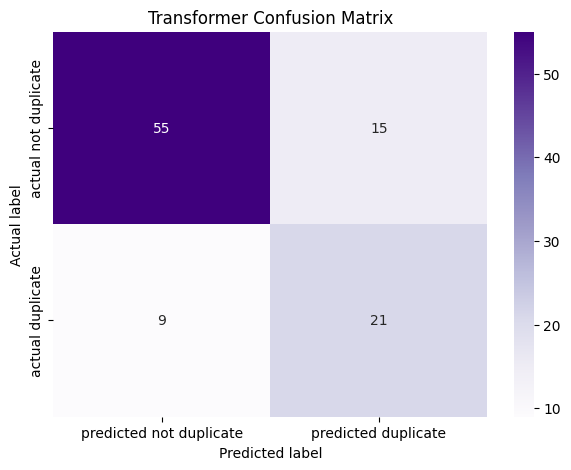

In [151]:
# printing the confusion matrix
cm_transformer = confusion_matrix(y_test_transformer, y_pred_transformer, labels=[0, 1])
cm_transformer_df = pd.DataFrame(
    cm_transformer,
    index=["actual not duplicate", "actual duplicate"],
    columns=["predicted not duplicate", "predicted duplicate"]
)

print("Transformer confusion matrix:")
display(cm_transformer_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_transformer_df, annot=True, fmt="d", cmap="Purples")
plt.title("Transformer Confusion Matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()


Now, after I got the results from Task 5 model, I will compare it with Task 4 model.

This is AI-generated code, so I asked Claude to help me generate a code cell to compare the evaluation performance of the Siamese LSTM models and the fine-tuned pre-trained Transformer.

However, I still also have my own deeper analysis on the comparison and the produced results, so this code is just to observe the overall results in comparison between two trained models.


In [166]:
# I am creating a comparison table of the evaluation metrics for both the Siamese LSTM and Transformer-based models,
# including accuracy, precision, recall, and F1-score to assess the performance of the two models on the same test set.
transformer_vs_siamese_df = pd.DataFrame([
    {
        "model": "Siamese LSTM",
        "accuracy": accuracy_siamese,
        "precision": precision_siamese,
        "recall": recall_siamese,
        "f1": f1_siamese
    },
    {
        "model": "Transformer BERT",
        "accuracy": accuracy_transformer,
        "precision": precision_transformer,
        "recall": recall_transformer,
        "f1": f1_transformer
    }
]).round(4)

display(transformer_vs_siamese_df)

,model,accuracy,precision,recall,f1
0,Siamese LSTM,0.60,0.3810,0.5333,0.4444
1,Transformer BERT,0.76,0.5833,0.7000,0.6364


In [167]:
# I am comparing the precision and recall of the Transformer-based model with the Siamese LSTM model to analyze how the pre-trained contextual representation affected the balance of predictions.
precision_change = precision_transformer - precision_siamese
recall_change = recall_transformer - recall_siamese

print(
    f"Transformer precision changed by {precision_change:.4f} "
    f"and recall changed by {recall_change:.4f} compared with the Siamese LSTM."
)

if precision_change > 0 and recall_change > 0 and precision_change > recall_change:
    transformer_comparison_text = (
        "The Transformer improved both precision and recall, but mainly precision. "
        "This suggests that the pre-trained contextual representation made the model "
        "more careful with duplicate predictions while still capturing semantic similarity better "
        "than the LSTM trained from scratch on the small subset."
    )
elif precision_change > 0 and recall_change > 0:
    transformer_comparison_text = (
        "The Transformer improved both precision and recall. This suggests that the "
        "pre-trained contextual representation captured question meaning better than "
        "the LSTM trained from scratch on the small subset."
    )
elif precision_change > 0 and recall_change <= 0:
    transformer_comparison_text = (
        "The Transformer mainly improved precision, so it was more careful when "
        "predicting duplicate pairs. This suggests the pre-trained model reduced some "
        "false positives by using contextual meaning rather than only surface similarity."
    )
elif precision_change <= 0 and recall_change > 0:
    transformer_comparison_text = (
        "The Transformer mainly improved recall, so it found more duplicate pairs. "
        "This suggests it captured more semantic similarity, although it may still "
        "over-predict duplicates if precision did not also improve."
    )
else:
    transformer_comparison_text = (
        "The Transformer did not improve precision or recall in these results. A likely "
        "reason is that the reduced training subset is small, so fine-tuning may be unstable."
    )

print("Comparison:", transformer_comparison_text)

Transformer precision changed by 0.2024 and recall changed by 0.1667 compared with the Siamese LSTM.
Comparison: The Transformer improved both precision and recall, but mainly precision. This suggests that the pre-trained contextual representation made the model more careful with duplicate predictions while still capturing semantic similarity better than the LSTM trained from scratch on the small subset.


### Deeper Analysis on the Transformer and Siamese Comparison

The Transformer BERT model performs better than the Siamese LSTM across all reported metrics. The Siamese LSTM achieves accuracy `0.6000`, precision `0.3810`, recall `0.5333`, and F1-score `0.4444`. In comparison, the Transformer achieves accuracy `0.7600`, precision `0.5833`, recall `0.7000`, and F1-score `0.6364`. (you can check the results in details above)

The Transformer improves both precision and recall. Precision increases by `0.2024`, from `0.3810` to `0.5833`, while recall increases by `0.1667`, from `0.5333` to `0.7000`. This means the Transformer is not only finding more true duplicate question pairs, but is also making fewer incorrect duplicate predictions. Since the improvement in precision is slightly larger than the improvement in recall, the main gain is in precision.

This result suggests that the fine-tuned BERT model captures question meaning more effectively than the Siamese LSTM trained from scratch. The Siamese LSTM encodes each question separately and then compares the two representations using cosine similarity. This can capture some semantic similarity, but with only 1000 training examples, the model has limited data to learn reliable sentence representations as I have explained before in task 4 above. As a result, it may struggle with question pairs that are topically similar but not actually duplicates.

In contrast, BERT is already pre-trained on a large amount of text before doing the fine-tuning. During fine-tuning, it processes the two questions together as a sentence pair, which allows the model to consider contextual word meaning, word order, and interactions between the two questions. This would help to explain why it achieves both higher recall and higher precision than the Siamese LSTM.

Overall, I can see that the Transformer handles the QQP semantic similarity task better in my results. Its higher precision, recall, and F1-score suggest that pre-trained contextual representations are more effective for duplicate-question classification than training an LSTM-based Siamese model from scratch on only a small subset. I think if the Siamese LSTM model could be trained on a larger amount of data, it would be able to improve its performance.

Now, I will inspect 1 misclassified example and explain why it had this mistake.

In [168]:
# I will inspect one Transformer misclassified example then explain the mistake
misclassified_indices = np.where(y_pred_transformer != y_test_transformer)[0]


def duplicate_label_text(label): # this is a helper function to convert the numeric label into a string for easier interpretation of the misclassified examples
    return "duplicate (1)" if int(label) == 1 else "not duplicate (0)"

# This is a function to calculate the lexical overlap ratio between two questions, 
# which can be used to analyze misclassified examples by comparing the token overlap of the question pairs.
def lexical_overlap_ratio(question1, question2):
    q1_tokens = {
        token.lower() for token in word_tokenize(str(question1))
        if any(character.isalnum() for character in token)
    }
    q2_tokens = {
        token.lower() for token in word_tokenize(str(question2))
        if any(character.isalnum() for character in token)
    }

    if not q1_tokens or not q2_tokens:
        return 0.0
    return len(q1_tokens & q2_tokens) / min(len(q1_tokens), len(q2_tokens))

In [169]:
# I am checking if there are any misclassified examples by the Transformer model, 
# and if so, I am selecting one example to analyze.
if len(misclassified_indices) == 0:
    print("No Transformer misclassified examples were found in this 100-example test subset.")
else:
    misclassified_index = int(misclassified_indices[0])
    misclassified_example = eval_ds[misclassified_index]
    q1_example = misclassified_example["question1"]
    q2_example = misclassified_example["question2"]
    true_label = int(y_test_transformer[misclassified_index])
    predicted_label = int(y_pred_transformer[misclassified_index])
    overlap = lexical_overlap_ratio(q1_example, q2_example)

    print("Misclassified example index:", misclassified_index)
    print("Question 1:", q1_example)
    print("Question 2:", q2_example)
    print("True label:", duplicate_label_text(true_label))
    print("Predicted label:", duplicate_label_text(predicted_label))
    print(f"Lexical overlap ratio: {overlap:.2f}")

    if true_label == 0 and predicted_label == 1:
        if overlap >= 0.5:
            mistake_explanation = (
                "This is a false positive. The two questions share many words, so the "
                "model may have focused on lexical and topical similarity even though "
                "the intended meanings are different."
            )
        else:
            mistake_explanation = (
                "This is a false positive. The pair may discuss a similar topic, and the "
                "model may have treated topical relatedness as semantic duplication."
            )
    elif true_label == 1 and predicted_label == 0:
        if overlap < 0.5:
            mistake_explanation = (
                "This is a false negative. The duplicate questions use different wording, "
                "so the model may not have connected the paraphrase strongly enough after "
                "fine-tuning on only 1000 examples."
            )
        else:
            mistake_explanation = (
                "This is a false negative. Even with shared words, small wording changes "
                "or ambiguity in QQP may have made the model judge the meanings as different."
            )
    else:
        mistake_explanation = (
            "This example is difficult because QQP questions can be short, informal, and "
            "ambiguous, so the duplicate boundary is sometimes unclear."
        )

    print("Explanation:", mistake_explanation)

Misclassified example index: 4
Question 1: What are some good baby girl names starting with D?
Question 2: What are some good baby girl names starting with D or H?
True label: not duplicate (0)
Predicted label: duplicate (1)
Lexical overlap ratio: 1.00
Explanation: This is a false positive. The two questions share many words, so the model may have focused on lexical and topical similarity even though the intended meanings are different.


### Deeper Analysis on the Misclassified Transformer Example

The Transformer misclassified this pair as duplicate even though the true label is not duplicate. The two questions are almost identical on the surface and have a lexical overlap ratio of `1.00`. Both ask for good baby girl names starting with `D`, so it is understandable that the model considered them highly similar.

However, the second question adds `or H`, which is a really small change but it changes the meaning of the whole sentence question. The first question only asks for names starting with `D`, while the second question asks for names starting with either `D` or `H`. This makes the second question broader, because it allows a larger set of possible answers. Therefore, the two questions are related, but they are not semantically equivalent, and do not exactly share the same meaning.

This is a false positive error. I think that a likely reason is that the model focused strongly on the shared wording and topic, such as "good baby girl names starting with", and did not give enough weight to the small but important constraint introduced by `or H`. This example shows that even a fine-tuned Transformer can still make mistakes when two questions have very high surface similarity but differ in a subtle semantic condition.

## Appendix:

I want to sincerely thanks to the resources and knowledge from pratical labs that helped and supported me a lots in successfully finishing this assignment. Also, I really appreciate all the efforts from all tutors in guiding us.

### Use of AI generators in this assignment

I used AI tools during this assignment to help with planning, code structure, debugging, and also doing something related to dataset overview and visualization to help me have a clearer view of the dataset. Also, I mainly used it for some less important tasks like code for comparison, code for displaying confusion matrix, etc.

The tools I used were ChatGPT and Claude.

The AI-generated or AI-assisted parts included:
- the system/GPU diagnostic code cell used to check my local Python, CUDA, PyTorch, and GPU environment;
- the dataset overview and visualisation code used to inspect the QQP dataset;
- the Task 3 confusion matrix error-analysis code;
- the Task 4 comparison code between Naive Bayes and the Siamese LSTM;
- the Task 5 comparison code between the Siamese LSTM and Transformer model;
- the Task 5 misclassified-example inspection code, including the helper function for lexical overlap and the automatic explanation for false positive or false negative cases;
- help with debugging notebook errors, such as replacing `encode_plus()` with the supported tokenizer call.
- i also get help to do with displaying and printing out one Transformer misclassified example.

The prompts I used included:
- "Please help me generate a standalone Python script that uses `sys`, `platform`, `subprocess`, and `torch` to print detailed Python, system, CUDA, cuDNN, GPU, PyTorch, memory, and `nvidia-smi` diagnostic information with clean formatting and graceful error handling."

- "Generate Python code that inspects a confusion matrix (`cm_nb`) for a Naive Bayes QQP classifier, compares false positives and false negatives, identifies the dominant error type, and prints an explanation based on Bag-of-Words limitations." (I still have my own deeper analysis on all the tasks, so this one is just for observation purpose, it will not replace my own explanation and words.)

- "Generate Python code to inspect one misclassified Transformer example for a QQP classifier, print the two questions, true label, predicted label, lexical overlap, and provide a short explanation for likely false positive or false negative errors." (Of course, I will still have my own analysis on this task, it will not replace my own explanation on this task)

- I also asked AI tools to help generate comparison code for Naive Bayes vs Siamese LSTM and Siamese LSTM vs Transformer.

- "please help me to generate Python code to find the first misclassified Transformer prediction using y_pred_transformer, y_test_transformer, eval_ds, np, and word_tokenize. Print question1, question2, true/predicted labels, lexical overlap, and a short false positive/false negative explanation."



I modified the generated output to match the assignment requirements, the QQP dataset structure, and my notebook variables. I checked the code outputs, adjusted the explanations to match my actual results, fixed errors, and added my own analysis for the model comparisons and misclassified examples. When the GenAI tools generated code for me, I still need to double check many times to ensure the code are compatible with my current environment variables, and other things that could negatively affect my whole notebook.